# **Máster en Behavioral Data Science** - Instituto de Formación Continua (IL3) - Universitat de Barcelona
## **Módulo 7: Aprendizaje Automático - Reto II**
Autor: **Meysam Madadi**

Colaborador: **Julio C. S. Jacques Junior**

---

# Antes de empezar
- Cada vez que se requiera una respuesta (o fragmento de código) habrá un texto en rojo o un comentario en una celda de código. Deberás (hacer doble clic en la celda y) proporcionar la información solicitada.
- Se recomienda crear una copia de este archivo para que puedas practicar todo lo que necesites antes de entregar la tarea.
- **No cambies la estructura ni el formato** de este archivo.
- Cuando hayas terminado, haz clic en "File", "Download", **"Dowload .ipynb"**.
- Nombra el archivo descargado como "**Nombre_Apellido_Reto_2.ipynb**" antes de enviarlo.

---
# Información personal
<font color='red'>(Haga doble clic en esta celda e informe...)</font>

<font color='red'>**Nombre completo:**</font>Lourdes Casado Vidigal; Mónica
Pachón Basallo; Michel Fernando Redondo Silva; María Meritxell Ruiz Muñoz; Pamela Valembois Madrigal

---

# **Reto 2:** Técnicas de clasificación binaria supervisada para la predicción de diabetes utilizando datos tabulares.


* Debido a la presencia de una fase asintomática relativamente larga, siempre es deseable una detección temprana de la diabetes. Alrededor del 50% de las personas que padecen esta enfermedad no están diagnosticadas debido a dicha fase. El [conjunto de datos](https://https://www.kaggle.com/datasets/andrewmvd/early-diabetes-classification) utilizado en este reto contiene 520 muestras (cada una con 17 características), recopiladas mediante cuestionarios directos y resultados de diagnóstico de pacientes en el Hospital de Diabetes de Sylhet, Bangladesh.

# Descargando los datos
- Los datos se descargarán al ejecutarse la siguiente celda
- Los datos descargados se pueden encontrar usando la interfaz de Colab (en la parte izquierda de esta ventana, en la pestaña "Files")

In [1]:
# descargando los datos
!wget https://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/diabetes_data.csv

--2026-06-27 10:08:59--  https://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/diabetes_data.csv
Resolving data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)... 158.109.8.83
Connecting to data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)|158.109.8.83|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20859 (20K) [application/octet-stream]
Saving to: ‘diabetes_data.csv’

diabetes_data.csv   100%[===================>]  20.37K   109KB/s    in 0.2s    

2026-06-27 10:09:01 (109 KB/s) - ‘diabetes_data.csv’ saved [20859/20859]



# Visualizando los datos

A continuación, se cargan y visualizan los datos: se separan los atributos categóricos y numéricos, y se cuenta el número de muestras para cada categoría o rango.

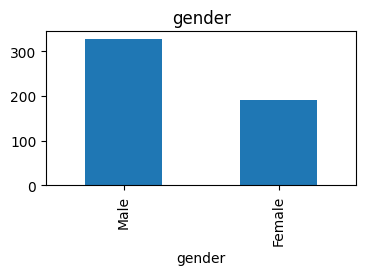

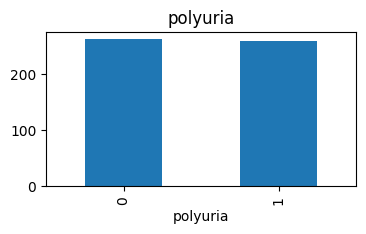

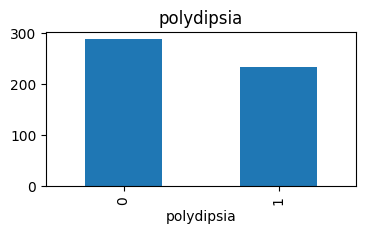

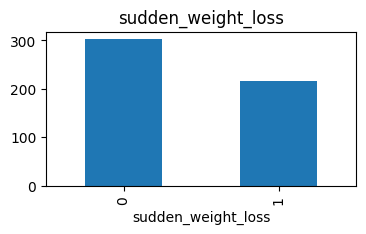

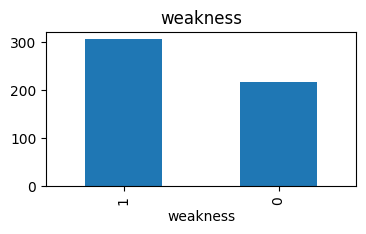

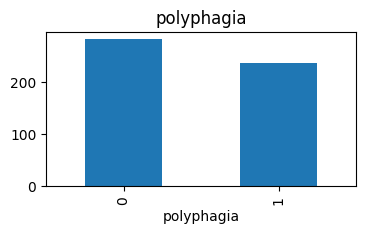

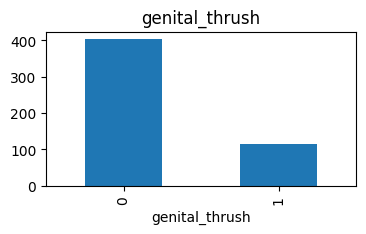

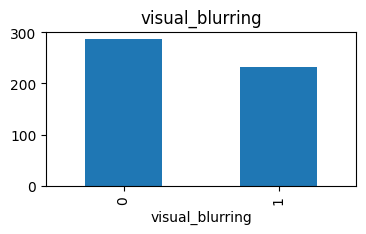

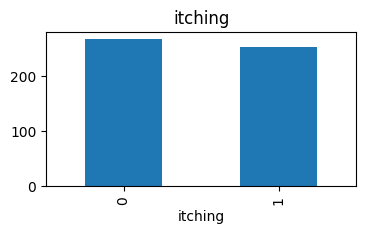

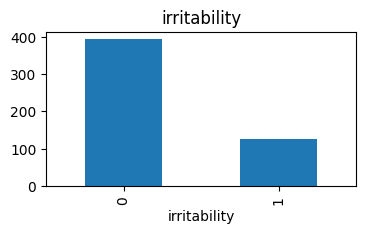

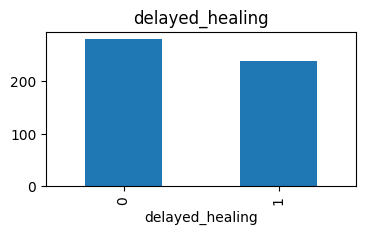

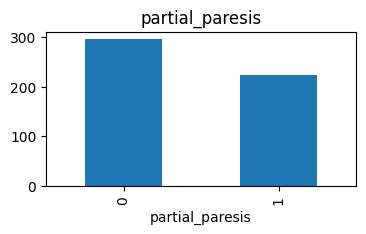

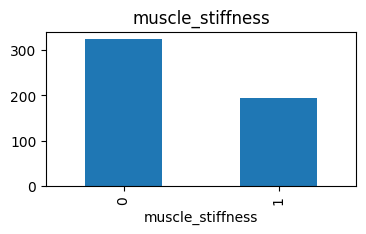

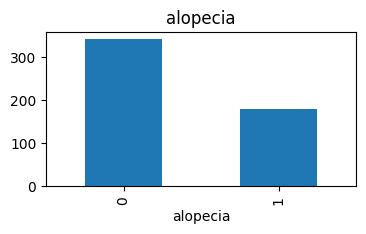

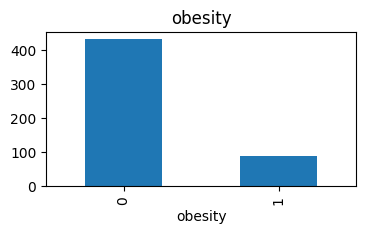

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargando los datos en un dataframe de pandas
df = pd.read_csv('diabetes_data.csv')

# Visualizando los atributos categóricos
for h in ['gender','polyuria','polydipsia','sudden_weight_loss','weakness','polyphagia','genital_thrush','visual_blurring','itching','irritability','delayed_healing','partial_paresis','muscle_stiffness','alopecia','obesity']:
    plt.figure(figsize=(4,2))
    df[h].value_counts().plot(kind='bar')
    plt.title(h)
    plt.show()

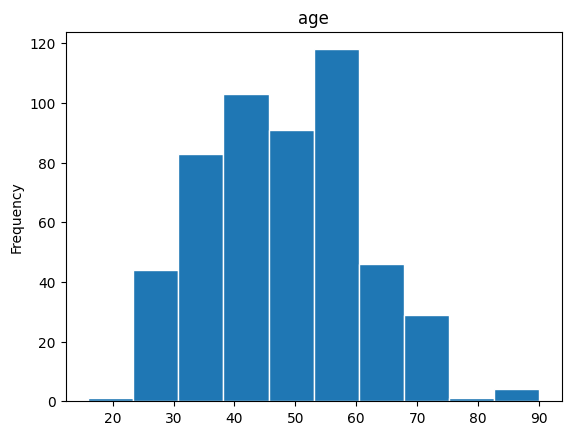

In [3]:
# Visualizando los atributos numéricos
for h in ['age']:
    df[h].plot.hist(edgecolor="white",bins=10)
    plt.title(h)
    plt.show()

---
# **TAREA 1:** Visualizando e interpretando los datos



**1.A Según los gráficos generados, ¿qué atributos categóricos binarios presentan un desbalance significativo, es decir, donde una de las categorías concentra más del 75% de las muestras?** (0.5 puntos) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>Según los gráficos de barras, tres atributos categóricos binarios destacan por tener una categoría claramente mayoritaria, en todos los casos la categoría 0 (ausencia del síntoma): obesity, genital_thrush e irritability. Estos tres se distinguen con nitidez del resto: en los demás atributos la categoría mayoritaria no llega a dos tercios de las muestras (por ejemplo, alopecia, gender o muscle_stiffness rondan el 62-66%), un desbalance moderado y por debajo del umbral. De los tres, obesity es el caso más evidente: la barra de la categoría 0 es varias veces mayor que la de la categoría 1, lo que sitúa la mayoría claramente por encima del 75% (en torno al 80%). En genital_thrush e irritability la categoría 0 también domina, situándose la mayoría aproximadamente entre el 75% y el 80%; no obstante, al estar su proporción muy cerca de la línea del 75%, son casos limítrofes en los que la inspección visual muestra un desbalance fuerte, pero no basta por sí sola para confirmar con total seguridad que se supera ese umbral exacto.

**1.B Dividiendo el atributo "edad" en rangos de 10 años (0-9, 10-19, 20-29, ..., 90-99), ¿qué rango de edad tiene el mayor número de casos de diabetes (atributo 'class' en la variable 'df')? Escriba la respuesta a continuación y proporcione un fragmento de código que lo respalde. Es decir, un código que cuente y muestre la categoría de edad con mayor número de casos positivos de diabetes.** <font color='blue'> (1 punto) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>
El rango de edad con mayor número de casos positivos de diabetes es 40-49 años (88 casos). Le siguen los rangos 50-59 (81 casos) y 30-39 (77 casos). Entre los casos positivos observados, la mayoría se concentra entre los 30 y los 59 años, mientras que en los grupos más jóvenes (10-29) y de mayor edad (70-99) aparecen muy pocos casos. Sin embargo, este resultado debe interpretarse teniendo en cuenta que la distribución general de edades en la muestra también se concentra entre los 30 y los 60 años; el análisis realizado se basa en recuentos absolutos y no permite concluir directamente que la diabetes sea más frecuente en ese tramo de edad.

In [4]:
# Filtrar los casos positivos de diabetes (class == 1)
positivos = df[df['class'] == 1]

# Dividir la edad en rangos de 10 años
bins = list(range(0, 101, 10))
etiquetas = [f'{i}-{i+9}' for i in range(0, 100, 10)]
rangos = pd.cut(positivos['age'], bins=bins, right=False, labels=etiquetas)

# Contar los casos positivos por rango de edad
conteo = rangos.value_counts().sort_index()
print(conteo)

# Mostrar el rango con mayor número de casos positivos
print('\nRango con más casos positivos:', conteo.idxmax(), '->', conteo.max(), 'casos')

age
0-9       0
10-19     1
20-29     7
30-39    77
40-49    88
50-59    81
60-69    56
70-79     6
80-89     2
90-99     2
Name: count, dtype: int64

Rango con más casos positivos: 40-49 -> 88 casos


---
# **TAREA 2:** Preprocesamiento de datos & Generando nuestros conjuntos de entrenamiento, validación y prueba
- A continuación, practicarás cómo preparar los datos para una tarea de clasificación. Primero, convertiremos las columnas categóricas en numéricas asignando a cada categoría un número único por columna. Podríamos representarlas mediante vectores one-hot; sin embargo, los atributos categóricos de este conjunto de datos son binarios, por lo que los mantendremos como 0 o 1. Finalmente, dividiremos los datos en conjuntos de entrenamiento, validación y prueba.

In [5]:
import pandas as pd
df = pd.read_csv('diabetes_data.csv', delimiter=',', skipinitialspace=True)

# Mapeando valores no numéricos a una secuencia de enteros, en este caso (0 y 1)
df['gender'] = df['gender'].map({'Male':0, 'Female':1})

# Mostrando las primeras cinco filas. Asegúrese de que no haya valores NaN, que no son válidos.
df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,0,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,0,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


## Definiendo nuestros conjuntos de entrenamiento/validación/prueba

A continuación, dividimos los datos en conjuntos de entrenamiento, validación y prueba. Asignamos las muestras a cada conjunto de forma aleatoria, asegurando una distribución equilibrada de clases positivas y negativas en los conjuntos de validación (100 muestras) y prueba (100 muestras). Las etiquetas (ground truth) están representadas por el atributo "class".

**2.A En esta tarea, necesitas crear los datos de entrenamiento, definidos como "X_train", y las etiquetas de entrenamiento, como "y_train", utilizando las muestras restantes. En la siguiente celda, se emplean valores aleatorios para el conjunto de entrenamiento. Debes reemplazar las dos líneas de código resaltadas para cargar correctamente el conjunto de entrenamiento.** </font> <font color='blue'> (1.5 puntos) </font>
- <font color='red'> **Importante:** Crear el conjunto de entrenamiento de manera adecuada es crucial para contestar las siguientes preguntas.



In [6]:
import numpy as np

# Convirtiendo el pandas dataframe en un numpy array para usar en los clasificadores
X = []
for h in ['age','gender','polyuria','polydipsia','sudden_weight_loss','weakness','polyphagia','genital_thrush','visual_blurring','itching','irritability','delayed_healing','partial_paresis','muscle_stiffness','alopecia','obesity']:
  X.append(df[h].to_numpy())
X = np.array(X, np.float32).T
Y = df['class'].to_numpy()

# Normalizando los datos en el rango [0..1]
X /= X.max(axis=0, keepdims=True)

# Obteniendo índices para muestras negativas y positivas
neg_idx = np.where(Y==0)[0]
pos_idx = np.where(Y==1)[0]

# Permutar aleatoriamente las muestras
np.random.seed(7)
neg_idx = neg_idx[np.random.permutation(neg_idx.shape[0])]
pos_idx = pos_idx[np.random.permutation(pos_idx.shape[0])]

# Creando conjuntos de validación y prueba balanceados con igual número de muestras positivas y negativas
# Las características y etiquetas se mantienen en X_<set> e y_<set> respectivamente, donde <set> es "train", "val" o "test"
X_test = np.concatenate([X[neg_idx[:50]], X[pos_idx[:50]]], axis=0)
y_test = np.concatenate([Y[neg_idx[:50]], Y[pos_idx[:50]]], axis=0)

X_val = np.concatenate([X[neg_idx[50:100]], X[pos_idx[50:100]]], axis=0)
y_val = np.concatenate([Y[neg_idx[50:100]], Y[pos_idx[50:100]]], axis=0)


# =================================================
''' Escribe tu código a continuación.
    Recuerda que debes modificar las dos líneas siguientes '''
# =================================================

# Cargar las muestras restantes como conjunto de entrenamiento
X_train = np.concatenate([X[neg_idx[100:]], X[pos_idx[100:]]], axis=0)
y_train = np.concatenate([Y[neg_idx[100:]], Y[pos_idx[100:]]], axis=0)


---
# **TAREA 3:** Clasificación binaria y ajuste de hiperparámetros.
- En esta tarea, practicarás con una clasificación binaria utilizando los siguientes algoritmos:
 - K-Nearest Neighbors (KNN)
 - Support Vector Machine (SVM)
 - Random Forest (RF)

- También experimentarás con el ajuste de hiperparámetros y evaluarás los resultados utilizando diferentes métricas.
- En la siguiente celda, entrenamos y evaluamos un clasificador KNN utilizando la precisión (*accuracy*) como métrica. Además, analizamos el impacto del hiperparámetro "k" (número de vecinos).

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score, f1_score

scores = {0:['Train', 'Validation', 'Test']}

# Iteramos sobre los hiperparámetros utilizando un bucle y monitoreamos los resultados
# (los guardamos en "scores")
for k in range(2, 16):
    # construyendo el clasificador
    clf = KNeighborsClassifier(n_neighbors = k)

    # Entrenando al clasificador usando los datos de entrenamiento
    clf.fit(X_train, y_train)

    # Realizando la inferencia para predecir las etiquetas
    pred_train = clf.predict(X_train)
    pred_val = clf.predict(X_val)
    pred_test = clf.predict(X_test)

    # Evaluando las predicciones con respecto a las etiquetas reales
    training_score = accuracy_score(y_train, pred_train)
    val_score = accuracy_score(y_val, pred_val)
    test_score = accuracy_score(y_test, pred_test)

    # Guardando el rendimiento del hiperparámetro k
    scores[k] = [training_score, val_score, test_score]

# Imprimiendo los resultados para cada hiperparámetro
for keys, values in scores.items():
    print(keys, ':', values)

0 : ['Train', 'Validation', 'Test']
2 : [0.959375, 0.99, 0.94]
3 : [0.96875, 0.97, 0.92]
4 : [0.95, 0.96, 0.89]
5 : [0.9625, 0.96, 0.89]
6 : [0.934375, 0.93, 0.88]
7 : [0.940625, 0.94, 0.88]
8 : [0.9375, 0.94, 0.9]
9 : [0.946875, 0.94, 0.89]
10 : [0.925, 0.91, 0.89]
11 : [0.928125, 0.91, 0.88]
12 : [0.91875, 0.91, 0.89]
13 : [0.91875, 0.91, 0.89]
14 : [0.915625, 0.91, 0.89]
15 : [0.925, 0.92, 0.89]


**3.A. Basándose en los resultados de KNN, ¿cuál es el mejor hiperparámetro k? ¿En qué conjunto debe verificarse para responder a esta pregunta: entrenamiento, validación o prueba? Justifique la respuesta.** <font color='blue'> (1 punto) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

El mejor hiperparámetro es **k = 2**, que alcanza la mayor precisión en el conjunto de validación (0.990). El valor de k debe verificarse en el conjunto de validación, y no en entrenamiento ni en prueba. **No en entrenamiento:** el modelo ya ha visto esos datos, por lo que la precisión ahí mide memorización y no capacidad de generalización. Valores pequeños de k tienden a sobreajustar y dar buenos resultados en entrenamiento sin garantizar un buen desempeño con datos nuevos. **No en prueba:** el conjunto de prueba se reserva para la evaluación final e imparcial del modelo. Si se usara para elegir k, se filtraría información de prueba en la selección del modelo (data leakage) y la estimación final del rendimiento quedaría sesgada (demasiado optimista). **Sí en validación:** es un conjunto de datos no vistos en el entrenamiento, destinado precisamente a comparar configuraciones de hiperparámetros y seleccionar la mejor.

- Los resultados de KNN en la celda anterior se evaluaron utilizando la precisión (*accuracy*) como métrica.
- En la siguiente celda, se encuentra un bucle que ejecuta el entrenamiento de KNN dos veces: una con los datos originales y otra con ruido aleatorio agregado a los datos. Luego, se estudiará el impacto del ruido usando diferentes métricas.
- **Actualice el hiperparámetro "k" en la siguiente celda según el mejor valor definido en la pregunta anterior. Después, ejecute la celda.**



In [8]:
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score, f1_score

scores = {0:['Train', 'Validation', 'Test']}

#===================================================
'''reemplace k con el mejor hiperparámetro encontrado en la tarea anterior'''
k = 2
#===================================================

# construyendo el clasificador
clf = KNeighborsClassifier(n_neighbors = k)

for i in range(2):
  train_noise = 0
  val_noise = 0
  test_noise = 0
  # Agregando ruido a los datos en la segunda iteración
  if i>0:
    np.random.seed(1)
    train_noise = 0.5-np.random.rand(X_train.shape[0], X_train.shape[1])
    val_noise = 0.5-np.random.rand(X_val.shape[0], X_val.shape[1])
    test_noise = 0.5-np.random.rand(X_test.shape[0], X_test.shape[1])

  # Entrenando al clasificador
  clf.fit(X_train+train_noise, y_train)

  # Haciendo inferencias para predecir las etiquetas
  pred_train = clf.predict(X_train+train_noise)
  pred_val = clf.predict(X_val+val_noise)
  pred_test = clf.predict(X_test+test_noise)

  # Evaluando las predicciones con respecto a las etiquetas de ground truth.
  # (usando diferentes métricas)
  for f in [accuracy_score, average_precision_score, roc_auc_score, f1_score]:
      training_score = f(y_train, pred_train)
      val_score = f(y_val, pred_val)
      test_score = f(y_test, pred_test)

      # Guardando los valores obtenidos
      scores[f.__name__] = [training_score, val_score, test_score]

  # Imprimiendo los resultados de cada métrica
  print('**** El conjunto de datos SIN ruido ****' if i==0 else '**** El conjunto de datos CON ruido ****')
  for keys, values in scores.items():
      print(keys, ':', values)
  print('')
  print('')

**** El conjunto de datos SIN ruido ****
0 : ['Train', 'Validation', 'Test']
accuracy_score : [0.959375, 0.99, 0.94]
average_precision_score : [np.float64(0.9815340909090909), np.float64(0.99), np.float64(0.94)]
roc_auc_score : [np.float64(0.9704545454545455), np.float64(0.99), np.float64(0.94)]
f1_score : [0.9695550351288056, 0.98989898989899, 0.9361702127659575]


**** El conjunto de datos CON ruido ****
0 : ['Train', 'Validation', 'Test']
accuracy_score : [0.925, 0.94, 0.86]
average_precision_score : [np.float64(0.9659090909090909), np.float64(0.9136), np.float64(0.8342857142857143)]
roc_auc_score : [np.float64(0.9454545454545454), np.float64(0.94), np.float64(0.86)]
f1_score : [0.9423076923076923, 0.94, 0.8478260869565217]




**3.B. Teniendo en cuenta los resultados anteriores (con y sin ruido), ¿qué métrica parece ser más sensible al ruido en este caso? ¿Qué se ha observado para responder a esta pregunta?** <font color='blue'> (1 punto) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

La métrica más sensible al ruido es la **precisión promedio** (average_precision_score). Al comparar cada métrica antes y después de añadir ruido, la precisión promedio es la que más disminuye en los conjuntos de validación y prueba. En prueba pasa de 0.940 a 0.834 (una caída de aproximadamente 0.11), y en validación de 0.990 a 0.914 (alrededor de 0.076). En cambio, accuracy, ROC-AUC y F1 caen menos y de forma similar entre sí (cerca de 0.05 en validación y 0.08 en prueba). Por eso, la precisión promedio es la que refleja con mayor intensidad el impacto del ruido en este caso.

- A continuación, se entrena un clasificador SVM y uno de Random Forest (RF), y se evalúan algunos de sus hiperparámetros.
 - Para el SVM, se evalúan el tipo de kernel ("lineal" y "RBF") y el parámetro de regularización C.
 - Para el RF, se evalúan el número de estimadores ("*n_estimators*") y la profundidad máxima del árbol ("*max_depth*").
- **Ejecute las siguientes dos celdas y responda las preguntas que se presentan a continuación.**



In [9]:
from sklearn import svm
from sklearn.metrics import f1_score as f

scores = {0:['Train', 'Validation', 'Test']}

for k in ['linear', 'rbf']:
    for reg in [0.1, 0.5, 1.0, 2.0]:

        # creando un clasificador SVM
        clf = svm.SVC(kernel=k, C=reg)

        clf.fit(X_train, y_train)

        pred_train = clf.predict(X_train)
        pred_val = clf.predict(X_val)
        pred_test = clf.predict(X_test)

        training_score = f(y_train, pred_train)
        val_score = f(y_val, pred_val)
        test_score = f(y_test, pred_test)
        scores[k+'_'+str(reg)] = [training_score, val_score, test_score]

for keys, values in scores.items():
    print(keys, ':', values)

0 : ['Train', 'Validation', 'Test']
linear_0.1 : [0.9594594594594594, 0.9056603773584906, 0.86]
linear_0.5 : [0.9701149425287356, 0.9230769230769231, 0.86]
linear_1.0 : [0.9724770642201835, 0.9230769230769231, 0.86]
linear_2.0 : [0.9634703196347032, 0.9230769230769231, 0.86]
rbf_0.1 : [0.9508928571428571, 0.8909090909090909, 0.8468468468468469]
rbf_0.5 : [0.9931972789115646, 0.9245283018867925, 0.8932038834951457]
rbf_1.0 : [0.9977324263038548, 0.9514563106796117, 0.9108910891089109]
rbf_2.0 : [0.9977324263038548, 0.9523809523809523, 0.9108910891089109]


**3.C. ¿Cuál es el "mejor" kernel al usar SVM en este caso? ¿Tiene la regularización el mismo impacto en ambos kernels? Explica brevemente tu respuesta.** <font color='blue'> (1 punto) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

El "mejor" kernel al usar SVM en este caso es el RBF, dado que alcanza valores más altos tanto en validación (0.95, C=2.0) como en prueba (0.91, C=1.0 y 2.0). Estos resultados superan al kernel lineal, que tiene su mejor F1 en validación (0.92) y en prueba (0.86).
La regularización no tiene el mismo impacto en ambos kernels. Para el kernel lineal, el parámetro C apenas afecta su rendimiento. Sólo puede trazar una frontera recta, tiene una capacidad limitada, y los datos tienen buena separabilidad lineal, por lo que ajustar C no le da mucho margen. Los resultados son planos: el rendimiento del lineal en prueba se mantiene constante en 0.86 y en validación varía poco, pasando de 0.91 a 0.92 entre C=0.1 y C=2.0. En el kernel RBF, el impacto del parámetro C es significativo. Como puede trazar curvas complejas y es más flexible, sí mejora con el aumento de C (menor regularización) para ajustarse mejor. La F1 de prueba sube de 0.85 a 0.91 y la de validación de 0.89 a 0.95, estabilizándose alrededor de C=1.0/2.0.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score as f

# hemos fijado la semilla para generar resultados reproducibles
np.random.seed(456)

scores = {0:['Train', 'Validation', 'Test']}

for n in [2, 5, 10]:
    for d in [5, 10, 15]:
        # creando un clasificador RF
        clf = RandomForestClassifier(n_estimators = n, max_depth=d)

        # Entrenando el modelo en el conjunto de datos de entrenamiento
        clf.fit(X_train, y_train)

        pred_train = clf.predict(X_train)
        pred_val = clf.predict(X_val)
        pred_test = clf.predict(X_test)

        training_score = f(y_train, pred_train)
        val_score = f(y_val, pred_val)
        test_score = f(y_test, pred_test)
        scores[str(n)+'_'+str(d)] = [training_score, val_score, test_score]
for keys, values in scores.items():
    print(keys, ':', values)

0 : ['Train', 'Validation', 'Test']
2_5 : [0.9750566893424036, 0.8785046728971962, 0.8686868686868687]
2_10 : [0.9931350114416476, 0.9494949494949495, 0.9148936170212766]
2_15 : [0.9791183294663574, 0.9278350515463918, 0.851063829787234]
5_5 : [0.9792147806004619, 0.94, 0.8865979381443299]
5_10 : [0.9954545454545455, 0.9411764705882353, 0.8910891089108911]
5_15 : [1.0, 0.9615384615384616, 0.9108910891089109]
10_5 : [0.988558352402746, 0.9423076923076923, 0.9]
10_10 : [1.0, 0.9702970297029703, 0.9387755102040817]
10_15 : [0.9977220956719818, 0.9607843137254902, 0.9090909090909091]


**3.D. ¿Qué combinación de hiperparámetros es la mejor al utilizar RF en este caso? Entre el número de estimadores y la profundidad máxima, ¿cuál parece tener un mayor impacto en los resultados? Explica brevemente tu respuesta.** <font color='blue'> (1 punto) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

La mejor combinación de hiperparámetros al utilizar RF en este caso es n_estimators=10 y max_depth=10, que obtiene la F1 más alta tanto en validación (0.97) como en prueba (0.94).
Entre los hiperparámetros, el número de estimadores parece tener un impacto ligeramente mayor y más consistente en los resultados que la profundidad máxima. Cuando aumenta el número de árboles, la F1 media de validación crece de manera monótona y los resultados se vuelven más estables, sobre todo al pasar de 2 a 5 árboles. De hecho, las configuraciones con 2 árboles son las más erráticas, con 2_5 teniendo una F1 de validación de 0.88. La profundidad ayuda hasta 10, pero más allá tiende a estancarse o empeorar. Con 2 árboles la F1 de validación baja de 0.95 a 0.93 al cambiar la profundidad de 10 a 15, aunque la F1 de entrenamiento se mantiene muy alta (0.98). Esto sugiere sobreajuste con árboles más profundos.



---
# **TAREA 4:** Clasificación binaria utilizando una red neuronal artificial (ANN)
- A continuación, practicarás la tarea de clasificación binaria utilizando una red neuronal artificial (ANN), ajustando su arquitectura, aplicando regularización y utilizando la técnica de parada anticipada (*early stopping*).
- En la siguiente celda, se define una red neuronal con dos capas completamente conectadas (densas, o *Fully connected*), cada una con 256 nodos y una activación "ReLU", seguidas de una capa de "dropout" con una probabilidad de eliminación del 20%. Luego, se incluye una capa final (densa) con un solo nodo (dado que se trata de un problema de clasificación binaria) y activación "sigmoid". La red se entrenará durante 20 épocas utilizando el optimizador "Adam", la función de pérdida de entropía cruzada binaria (*binary_crossentropy*) y un tamaño de lote (*batch size*) de 32. Además, por razones de reproducibilidad, se fija la semilla aleatoria de Keras (*random_seed*).

- **Ejecute la siguiente celda y responda las preguntas que se presentan a continuación.**



In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout

keras.utils.set_random_seed(800)

model = keras.Sequential()
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=["accuracy"])

history = model.fit(X_train, y_train, batch_size=32, epochs=20, verbose=2, validation_data=(X_val, y_val))

test_score = model.evaluate(X_test, y_test, verbose=1)[1]
print("\ntest set accuracy is ", test_score)

Epoch 1/20
10/10 - 5s - 477ms/step - accuracy: 0.6656 - loss: 0.5433 - val_accuracy: 0.5000 - val_loss: 0.6144
Epoch 2/20
10/10 - 0s - 12ms/step - accuracy: 0.7750 - loss: 0.3766 - val_accuracy: 0.8500 - val_loss: 0.4145
Epoch 3/20
10/10 - 0s - 12ms/step - accuracy: 0.9094 - loss: 0.2724 - val_accuracy: 0.9200 - val_loss: 0.2887
Epoch 4/20
10/10 - 0s - 12ms/step - accuracy: 0.9344 - loss: 0.2029 - val_accuracy: 0.9200 - val_loss: 0.2350
Epoch 5/20
10/10 - 0s - 18ms/step - accuracy: 0.9531 - loss: 0.1539 - val_accuracy: 0.9500 - val_loss: 0.1879
Epoch 6/20
10/10 - 0s - 31ms/step - accuracy: 0.9656 - loss: 0.1231 - val_accuracy: 0.9200 - val_loss: 0.1790
Epoch 7/20
10/10 - 0s - 29ms/step - accuracy: 0.9625 - loss: 0.1073 - val_accuracy: 0.9400 - val_loss: 0.1585
Epoch 8/20
10/10 - 0s - 18ms/step - accuracy: 0.9719 - loss: 0.0824 - val_accuracy: 0.9300 - val_loss: 0.1603
Epoch 9/20
10/10 - 0s - 31ms/step - accuracy: 0.9750 - loss: 0.0698 - val_accuracy: 0.9400 - val_loss: 0.1483
Epoch 10/

**4.A Según los resultados anteriores, ¿podría ser beneficioso aplicar una parada anticipada del entrenamiento (*early stopping*)? Explica brevemente tu respuesta.** <font color='blue'> (0.5 puntos) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

Sí, podría ser beneficioso aplicar una parada anticipada del entrenamiento porque, aunque en el entrenamiento la pérdida sigue disminuyendo hasta el final y la precisión se mantiene muy alta (en la época 20 el accuracy es 0.99 y el loss 0.02), en la validación el rendimiento se estanca. La precisión se mantiene alrededor de 0.95-0.96 desde la época 11 y la pérdida de validación se estabiliza con oscilaciones, mejorando muy poco (entre 0.09 y 0.13).
Esta divergencia entre entrenamiento y validación indica un sobreajuste leve, en que el modelo sigue ajustándose a los datos de entrenamiento sin lograr mejoras equivalentes en datos no vistos. Una parada anticipada detendría el entrenamiento cerca de la época 11-12, cuando la precisión de validación deja de mejorar. Sin embargo, el beneficio sería sobre todo computacional, ya que la validación no se degrada significativamente.

- **Edite la siguiente celda de código para evaluar los siguientes hiperparámetros:**
 - El tamaño de las dos primeras capas densas (actualmente de tamaño 256). Pruebe con los siguientes valores:  <font color='blue'>[32, 64, 128, 256, 512]</font>, generando todas las combinaciones posibles.
 - Diferentes valores de *batch_size* en la función "*model.fit*". Pruebe con: <font color='blue'>[16, 32, 64, 128]</font>, teniendo en cuenta el ítem anterior. Es decir, evaluando todas las combinaciones posibles.
 - En el código siguiente, los mensajes de entrenamiento están ocultos mediante "verbose=0".
 - Consulte el código de la Tarea 3.B (RF) como referencia para inspirarse y ejecutar todos los experimentos en un solo bloque. Por ejemplo, utilizando tres bucles anidados para iterar sobre los distintos valores: uno para el tamaño de la primera capa densa, otro para el tamaño de la segunda capa densa y otro para el tamaño del *batch size*. Entrene los diferentes modelos en función de estos nuevos parámetros y evalúe los resultados.

- *La evaluación de todas estas combinaciones puede requerir una alta capacidad computacional. Se recomienda habilitar el uso de GPU en Colab para mejorar el rendimiento (Runtime -> Change runtime type -> T4 GPU).*

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout

# Todas las combinaciones posibles serían 5 x 5 x 4 = 100 modelos
capa1_sizes = [32, 64, 128, 256, 512]
capa2_sizes = [32, 64, 128, 256, 512]
batch_sizes = [16, 32, 64, 128]

scores = {0:['Train', 'Validation','Test']}

for s1 in capa1_sizes:
  for s2 in capa2_sizes:
    for bs in batch_sizes:

      keras.utils.set_random_seed(800)

      model = keras.Sequential()

      #===================================================
      ''' Cambiar el tamaño de la capa en la siguiente línea '''
      model.add(Dense(s1, activation='relu'))
      #===================================================

      model.add(Dropout(0.2))

      #===================================================
      ''' Cambiar el tamaño de la capa en la siguiente línea '''
      model.add(Dense(s2, activation='relu'))
      #===================================================

      model.add(Dropout(0.2))

      model.add(Dense(1, activation='sigmoid'))

      model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=["accuracy"])

      #===================================================
      ''' Cambiar el tamaño del 'batch size' en la siguiente línea '''
      history = model.fit(X_train, y_train, batch_size=bs, epochs=20, verbose=0, validation_data=(X_val, y_val))
      #===================================================

      # La precisión en los conjuntos de validación y prueba se puede extraer en las siguientes líneas.
      training_score = history.history['accuracy'][-1]
      val_score = history.history['val_accuracy'][-1]
      test_score = model.evaluate(X_test, y_test, verbose=0)[1]

      scores[f'{s1}_{s2}_bs{bs}'] = [training_score, val_score, test_score]

# Impresión de todas las combinaciones
for key, values in scores.items():
    print(key, ':', values)

combinaciones = {k: v for k, v in scores.items() if k != 0}
mejor = max(combinaciones, key=lambda k: combinaciones[k][1])
print('\nMejor combinacion segun validacion:', mejor, '->', scores[mejor])


0 : ['Train', 'Validation', 'Test']
32_32_bs16 : [0.965624988079071, 0.9200000166893005, 0.8600000143051147]
32_32_bs32 : [0.9312499761581421, 0.9200000166893005, 0.8500000238418579]
32_32_bs64 : [0.893750011920929, 0.8799999952316284, 0.7599999904632568]
32_32_bs128 : [0.768750011920929, 0.5799999833106995, 0.5899999737739563]
32_64_bs16 : [0.971875011920929, 0.9200000166893005, 0.8500000238418579]
32_64_bs32 : [0.9375, 0.9200000166893005, 0.8600000143051147]
32_64_bs64 : [0.921875, 0.8799999952316284, 0.7799999713897705]
32_64_bs128 : [0.878125011920929, 0.800000011920929, 0.7099999785423279]
32_128_bs16 : [0.9750000238418579, 0.9200000166893005, 0.8600000143051147]
32_128_bs32 : [0.949999988079071, 0.9200000166893005, 0.8700000047683716]
32_128_bs64 : [0.9281250238418579, 0.9200000166893005, 0.8600000143051147]
32_128_bs128 : [0.918749988079071, 0.8399999737739563, 0.75]
32_256_bs16 : [0.981249988079071, 0.9200000166893005, 0.8799999952316284]
32_256_bs32 : [0.949999988079071, 0.920

**4.B Basado en tus resultados, ¿cuál es la mejor combinación de hiperparámetros (tamaño de ambas capas y batch size)? ¿Has observado algún cambio o tendencia en la precisión evaluada en el conjunto de prueba al aumentar el tamaño de las capas? Explica brevemente tus respuestas.** <font color='blue'> (2.0 puntos) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

La mejor combinación de hiperparámetros según la precisión en validación es capa 1=64, capa 2=128, y batch_size=16 (validación=0.96, entrenamiento=1.00, y prueba=0.91).
Sin embargo, esa precisión de validación máxima también la alcanzan otras 31 combinaciones distintas. El conjunto de validación sólo tiene 100 muestras, la métrica avanza en saltos de 0.01, y se satura en 0.96. Por tanto, más que un ganador, hay un conjunto de modelos casi equivalentes empatados y 64_128_bs16 es el primero que encuentra la función max. Entre estos, los de capas 256-512 tienden a la precisión de prueba más alta y estable (0.92-0.93).
Sí se observa una tendencia: la precisión de prueba aumenta al crecer el tamaño de capas, pero con rendimientos decrecientes. En la capa 1, promediando todas las combinaciones, la precisión media de prueba aumenta de 0.82 (32 capas) a 0.87 (64), 0.89 (128), 0.90 (256) y 0.92 (512). En la segunda capa es similar. Esto es lo esperable de capacidad del modelo, dado que más neuronas dan más capacidad de representar patrones.

Sin embargo, es más marcada la mejora entre capas pequeñas a medianas (de 32 a 128), que cuando cambia a capas mayores (128 a 512). Posiblemente, esto es porque el dataset es sencillo, por lo que más de 128 neuronas es más capacidad de la necesaria y lleva a rendimientos decrecientes.

El batch_size también tiene un impacto: la precisión media de prueba en 16 es 0.91, mientras que en 128 es 0.83. Es decir que, con batches pequeños hay más actualizaciones de gradiente por época, por lo que en 20 épocas fijas el modelo entrena mejor. Las de mayor precisión de prueba suelen llevar batch 16.


**4.C La regularización Dropout ha sido eliminada del siguiente fragmento de código. Actualízalo con los mejores hiperparámetros encontrados en la Tarea 4.B y explica cómo cambian los resultados en los conjuntos de validación y prueba.** <font color='blue'> (0.5 puntos) </font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

Al eliminar el dropout y entrenar con los mejores hiperparámetros de 4.B (64_128_bs16), la precisión en validación (0.96) y en prueba (0.91) se mantiene igual que con dropout.
Quitar la regularización no mejora la generalización, y en este caso el modelo se ajusta igual al conjunto de entrenamiento: la precisión de entrenamiento se mantiene en 1.00, igual que con dropout. Es decir, eliminar el dropout tiene un efecto prácticamente nulo en los tres conjuntos (entrenamiento, validación y prueba), probablemente porque la red es pequeña y el problema es sencillo. Posiblemente, en un problema menos sencillo o una red más grande, la ausencia de dropout llevaría a un sobreajuste mayor.

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout

keras.utils.set_random_seed(800)

model = keras.Sequential()

#===================================================
''' Cambiar el tamaño de las capas en las siguientes líneas (si es necesario) '''
model.add(Dense(64, activation='relu'))
model.add(Dense(128, activation='relu'))
#===================================================

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(), metrics=["accuracy"])

#===================================================
''' Cambiar el tamaño del 'batch_size' en la siguiente línea (si es necesario) '''
history = model.fit(X_train, y_train, batch_size=16, epochs=20, verbose=2, validation_data=(X_val, y_val))
#===================================================

test_score = model.evaluate(X_test, y_test, verbose=0)[1]
print("\ntest set accuracy is ", test_score)

Epoch 1/20
20/20 - 2s - 121ms/step - accuracy: 0.6062 - loss: 0.6157 - val_accuracy: 0.5000 - val_loss: 0.6362
Epoch 2/20
20/20 - 0s - 10ms/step - accuracy: 0.6875 - loss: 0.4605 - val_accuracy: 0.5000 - val_loss: 0.5553
Epoch 3/20
20/20 - 0s - 11ms/step - accuracy: 0.8344 - loss: 0.3555 - val_accuracy: 0.8500 - val_loss: 0.4008
Epoch 4/20
20/20 - 0s - 15ms/step - accuracy: 0.9125 - loss: 0.2673 - val_accuracy: 0.9100 - val_loss: 0.3002
Epoch 5/20
20/20 - 0s - 11ms/step - accuracy: 0.9312 - loss: 0.2044 - val_accuracy: 0.9200 - val_loss: 0.2392
Epoch 6/20
20/20 - 0s - 11ms/step - accuracy: 0.9625 - loss: 0.1603 - val_accuracy: 0.9300 - val_loss: 0.2044
Epoch 7/20
20/20 - 0s - 12ms/step - accuracy: 0.9656 - loss: 0.1269 - val_accuracy: 0.9300 - val_loss: 0.1818
Epoch 8/20
20/20 - 0s - 11ms/step - accuracy: 0.9719 - loss: 0.1009 - val_accuracy: 0.9300 - val_loss: 0.1672
Epoch 9/20
20/20 - 0s - 8ms/step - accuracy: 0.9719 - loss: 0.0817 - val_accuracy: 0.9300 - val_loss: 0.1555
Epoch 10/2